c=0.03: V* converged after 67 iterations.
c = 0.03
Belief continue region: [0.166, 0.834]
Stop for b <= 0.166 or b >= 0.834
log10 evidence lower boundary: -0.701
log10 evidence upper boundary: 0.701


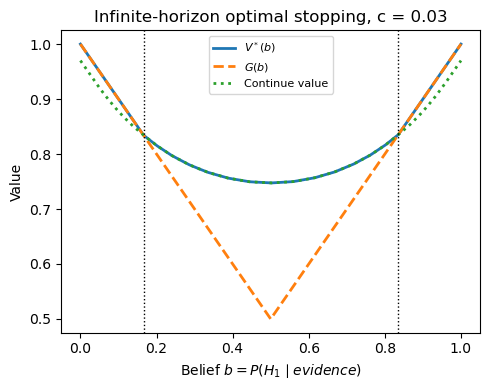

   trial  true_H  time_step  stim_idx  evidence_sum    belief  action  \
0      0       0          1        12           0.5  0.759747       2   
1      0       0          2         3           0.0  0.500000       2   
2      0       0          3        12           0.5  0.759747       2   
3      0       0          4         4           0.1  0.557312       2   
4      0       0          5         5          -0.2  0.386863       2   

  forced_final_choice  
0                 NaN  
1                 NaN  
2                 NaN  
3                 NaN  
4                 NaN  
action
2    189839
0     23062
1     22908
Name: count, dtype: int64


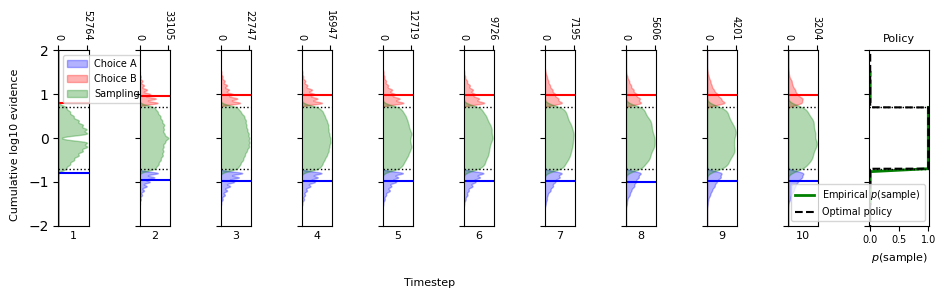

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

# ============================================================
# 1. Define 16 stimulus types and their probabilities under H0/H1
# ============================================================

mu = 2.2
sigma = 5.0
x = np.linspace(-15, 15, 500)

pdf_left = norm.pdf(x, -mu, sigma)   # H0 / Target A
pdf_right = norm.pdf(x, mu, sigma)   # H1 / Target B

# log10 likelihood ratio: log10 P(x|H1) / P(x|H0)
log_ratio = np.log10(pdf_right / pdf_left)

target_log_ratios = np.array([
    -0.8, -0.7, -0.6, -0.5,
    -0.4, -0.3, -0.2, -0.1,
     0.1,  0.2,  0.3,  0.4,
     0.5,  0.6,  0.7,  0.8
])

x_targets = np.interp(target_log_ratios, log_ratio, x)

pB_raw = norm.pdf(x_targets, mu, sigma)
pA_raw = norm.pdf(x_targets, -mu, sigma)

pB = pB_raw / pB_raw.sum()
pA = pA_raw / pA_raw.sum()

# ============================================================
# 2. Infinite-horizon value iteration with only c = 0.03
# ============================================================

c = 0.03

R_correct = 1.0
R_wrong = 0.0

N_b = 1001
b_grid = np.linspace(0, 1, N_b)

# Stop value: choose H1 if b >= 0.5, otherwise H0
G = np.maximum(
    b_grid * R_correct + (1 - b_grid) * R_wrong,
    (1 - b_grid) * R_correct + b_grid * R_wrong
)

def compute_V_star(pA, pB, c, b_grid, G, tol=1e-10, max_iter=100000):
    """
    Infinite-horizon value iteration.
    Belief b = P(H1 | evidence).
    H0 corresponds to pA, H1 corresponds to pB.
    """
    V = G.copy()

    for iteration in range(max_iter):
        V_old = V.copy()
        continue_value = np.zeros_like(b_grid)

        for j, b in enumerate(b_grid):
            expected_future_value = 0.0

            for i in range(len(pA)):
                q_i = b * pB[i] + (1 - b) * pA[i]

                if q_i > 0:
                    b_next = (b * pB[i]) / q_i
                    expected_future_value += q_i * np.interp(
                        b_next, b_grid, V_old
                    )

            continue_value[j] = -c + expected_future_value

        V = np.maximum(G, continue_value)

        diff = np.max(np.abs(V - V_old))
        if diff < tol:
            print(f"c={c:.2f}: V* converged after {iteration + 1} iterations.")
            break
    else:
        print("Warning: value iteration did not converge.")

    return V


def stopping_boundaries_from_Vstar(pA, pB, c, b_grid, G, V_star):
    """
    Stop if stop value >= continue value.
    Continue region lies between lower_boundary and upper_boundary.
    """
    continue_value = np.zeros_like(b_grid)

    for j, b in enumerate(b_grid):
        expected_future_value = 0.0

        for i in range(len(pA)):
            q_i = b * pB[i] + (1 - b) * pA[i]

            if q_i > 0:
                b_next = (b * pB[i]) / q_i
                expected_future_value += q_i * np.interp(
                    b_next, b_grid, V_star
                )

        continue_value[j] = -c + expected_future_value

    stop_region = G >= continue_value
    continue_region = ~stop_region

    if np.any(continue_region):
        lower_boundary = b_grid[continue_region][0]
        upper_boundary = b_grid[continue_region][-1]
    else:
        lower_boundary = 0.5
        upper_boundary = 0.5

    return lower_boundary, upper_boundary, stop_region, continue_value


V_star = compute_V_star(pA, pB, c, b_grid, G)

lower_b, upper_b, stop_region, continue_value = stopping_boundaries_from_Vstar(
    pA, pB, c, b_grid, G, V_star
)

print(f"c = {c:.2f}")
print(f"Belief continue region: [{lower_b:.3f}, {upper_b:.3f}]")
print(f"Stop for b <= {lower_b:.3f} or b >= {upper_b:.3f}")

# Convert belief boundaries to cumulative log10 odds boundaries
eps = 1e-12
lower_log_boundary = np.log10(
    np.clip(lower_b, eps, 1 - eps) / np.clip(1 - lower_b, eps, 1 - eps)
)
upper_log_boundary = np.log10(
    np.clip(upper_b, eps, 1 - eps) / np.clip(1 - upper_b, eps, 1 - eps)
)

print(f"log10 evidence lower boundary: {lower_log_boundary:.3f}")
print(f"log10 evidence upper boundary: {upper_log_boundary:.3f}")

# ============================================================
# 3. Plot V*(b), G(b), and continue value
# ============================================================

plt.figure(figsize=(5, 4))
plt.plot(b_grid, V_star, label=r"$V^*(b)$", linewidth=2)
plt.plot(b_grid, G, "--", label=r"$G(b)$", linewidth=2)
plt.plot(b_grid, continue_value, ":", label="Continue value", linewidth=2)

plt.axvline(lower_b, color="black", linestyle=":", linewidth=1)
plt.axvline(upper_b, color="black", linestyle=":", linewidth=1)

plt.xlabel(r"Belief $b=P(H_1 \mid evidence)$")
plt.ylabel("Value")
plt.title(f"Infinite-horizon optimal stopping, c = {c}")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ============================================================
# 4. Simulate 5 x 10^4 noiseless perfect-integration trials
# ============================================================

n_trials = 5 * 10**4
max_timestep = 10
prior_b = 0.5

rng = np.random.default_rng(1)

sim_rows = []

for trial in range(n_trials):

    # True hypothesis: 0 = H0 / Target A, 1 = H1 / Target B
    true_H = rng.integers(0, 2)

    evidence_sum = 0.0
    decided = False

    for t in range(1, max_timestep + 1):

        # Sample one stimulus according to the true hypothesis
        if true_H == 0:
            stim_idx = rng.choice(len(pA), p=pA)
        else:
            stim_idx = rng.choice(len(pB), p=pB)

        # Perfect noiseless integration of log10 likelihood ratio
        evidence_sum += target_log_ratios[stim_idx]

        # Convert cumulative log10 odds to belief
        # prior odds = 1, so log10 posterior odds = cumulative evidence
        b = 1.0 / (1.0 + 10.0 ** (-evidence_sum))

        # Apply optimal policy
        if b <= lower_b:
            action = 0   # choose A / H0
            decided = True
        elif b >= upper_b:
            action = 1   # choose B / H1
            decided = True
        else:
            action = 2   # continue sampling

        sim_rows.append({
            "trial": trial,
            "true_H": true_H,
            "time_step": t,
            "stim_idx": stim_idx,
            "evidence_sum": evidence_sum,
            "belief": b,
            "action": action
        })

        if decided:
            break

    # If still undecided at max timestep, force final choice by current belief
    sim_rows[-1]["forced_final_choice"] = False


# Convert to DataFrame
import pandas as pd
df_sim = pd.DataFrame(sim_rows)

print(df_sim.head())
print(df_sim["action"].value_counts())


colors = {
    0: "blue",
    1: "red",
    2: "green"
}

labels = {
    0: r'Chosen $H_0$', 
    1: r'Chosen $H_1$', 
    2: r'Sampling'
}

# ============================================================
# Figure layout: 15 timestep panels + 1 policy panel on right
# ============================================================

fig, axes = plt.subplots(
    1,
    max_timestep + 1,
    figsize=(10, 3),
    sharey=True,
    gridspec_kw={"width_ratios": [1] * max_timestep + [2.0]}
)

dist_axes = axes[:-1]
policy_ax = axes[-1]

y_min = -2
y_max = 2
y_grid = np.linspace(y_min, y_max, 400)

# ============================================================
# Left side: timestep-wise smoothed evidence distributions
# ============================================================

for t in range(1, max_timestep + 1):

    ax = dist_axes[t - 1]
    timestep_data = df_sim[df_sim["time_step"] == t]

    max_density = 0.0

    for action in [0, 1, 2]:

        action_data = timestep_data[timestep_data["action"] == action]

        if action_data.empty:
            continue

        ev = action_data["evidence_sum"].to_numpy()

        # KDE needs enough spread
        if len(ev) < 3 or np.std(ev) == 0:
            continue

        kde = gaussian_kde(ev)
        density = kde(y_grid)

        # Scale by count so width roughly reflects frequency
        density_scaled = density * len(ev)

        max_density = max(max_density, density_scaled.max())

        ax.fill_betweenx(
            y_grid,
            0,
            density_scaled,
            color=colors[action],
            alpha=0.3,
            label=labels[action] if t == 1 else None
        )

        # Mean evidence line for choice trials
        if action in [0, 1]:
            mean_ev = np.mean(ev)
            ax.axhline(
                mean_ev,
                color=colors[action],
                linewidth=1.5
            )

    # Decision boundaries in cumulative log10-odds
    ax.axhline(lower_log_boundary, color="black", linestyle=":", linewidth=1)
    ax.axhline(upper_log_boundary, color="black", linestyle=":", linewidth=1)

    ax.set_ylim(y_min, y_max)

    if max_density > 0:
        ax.set_xlim(0, max_density * 1.05)
        ax.set_xticks([0, int(max_density)])
    else:
        ax.set_xlim(0, 1)
        ax.set_xticks([0, 1])

    ax.xaxis.set_ticks_position("top")
    ax.tick_params(axis="x", top=True, labeltop=True, labelbottom=False)

    ax.set_xticklabels(
        [str(int(x)) for x in ax.get_xticks()],
        rotation=270,
        fontsize=7
    )

    ax.set_xlabel(str(t), fontsize=8)

# ============================================================
# Right side: policy curve p(sampling | cumulative log-odds)
# empirical proportion of action == 2 as a function of evidence
# ============================================================

all_ev = df_sim["evidence_sum"].to_numpy()
all_is_sampling = (df_sim["action"] == 2).astype(float).to_numpy()

# Bin cumulative log-odds
n_bins = 60
ev_bins = np.linspace(y_min, y_max, n_bins + 1)
ev_centers = 0.5 * (ev_bins[:-1] + ev_bins[1:])

p_sampling_emp = np.full_like(ev_centers, np.nan, dtype=float)
counts_per_bin = np.zeros_like(ev_centers, dtype=int)

for i in range(n_bins):
    mask = (all_ev >= ev_bins[i]) & (all_ev < ev_bins[i + 1])
    counts_per_bin[i] = mask.sum()
    if mask.sum() >= 10:   # avoid unstable estimates in sparse bins
        p_sampling_emp[i] = all_is_sampling[mask].mean()

# Theoretical optimal policy from the boundary
# p(sample)=1 inside continue region, 0 outside
eps = 1e-12
log_odds_grid = np.log10(
    np.clip(b_grid, eps, 1 - eps) / np.clip(1 - b_grid, eps, 1 - eps)
)
p_sampling_theory = ((b_grid > lower_b) & (b_grid < upper_b)).astype(float)

# Plot empirical curve
policy_ax.plot(
    p_sampling_emp,
    ev_centers,
    color="green",
    linewidth=2,
    label=r"Empirical $p(\mathrm{sample})$"
)

# Optional: overlay theoretical hard policy
policy_ax.plot(
    p_sampling_theory,
    log_odds_grid,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Optimal policy"
)

# Boundaries
policy_ax.axhline(lower_log_boundary, color="black", linestyle=":", linewidth=1)
policy_ax.axhline(upper_log_boundary, color="black", linestyle=":", linewidth=1)

policy_ax.set_xlim(-0.02, 1.02)
policy_ax.set_xticks([0, 0.5, 1.0])
policy_ax.set_xlabel(r"$p(\mathrm{sample})$", fontsize=8)
policy_ax.set_title("Policy", fontsize=8)
policy_ax.tick_params(axis="x", labelsize=7)

# ============================================================
# Shared labels and cosmetics
# ============================================================

fig.text(0.48, 0.03, "Timestep", ha="center", fontsize=8)
fig.text(
    0.06,
    0.5,
    "Cumulative log10 evidence",
    va="center",
    rotation="vertical",
    fontsize=8
)

for ax in dist_axes:
    ax.label_outer()

dist_axes[0].legend(loc="best", fontsize=7)
policy_ax.legend(loc="lower right", fontsize=7)

plt.tight_layout(rect=[0.05, 0.05, 1, 1])
plt.show()